In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

def load_abs_dat(absdatpath):
    absorption = np.loadtxt(absdatpath)
    energies = absorption.transpose()[0]
    alpha = absorption.transpose()[1]
    return (energies, alpha)

In [3]:
#Path to your data from your optical calculation goes here

absorption = load_abs_dat("absorption.dat")

Text(0.5, 0, '$h \\nu$ (eV)')

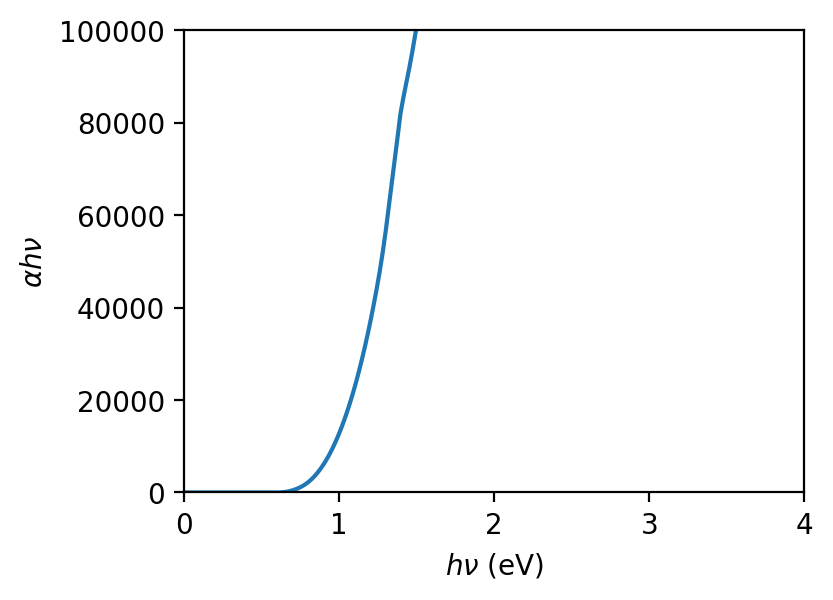

In [4]:
#This is just the absorption plot

f,ax = plt.subplots(dpi=200, figsize=(4,3))

ax.plot(absorption[0], absorption[1])
ax.set_xlim(0, 4)
ax.set_ylim(0, 1e5)
ax.set_ylabel(r"$\alpha h \nu$")
ax.set_xlabel(r"$h \nu$ (eV)")

Text(0.5, 0, '$h \\nu$ (eV)')

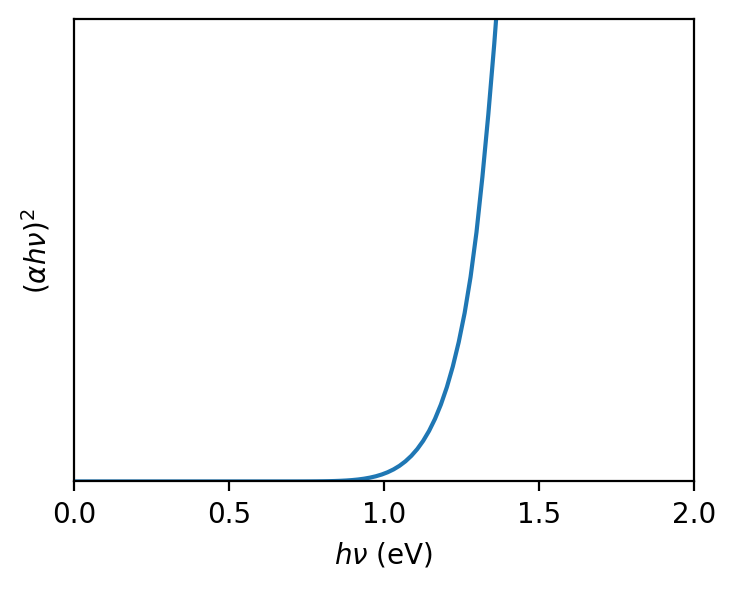

In [5]:
#This is the absorption squared plot. Depending on whether the material has a direct bandgap or an indirect bandgap, this may need to be ammended.
#This is only relavent for materials with a direct bandgap. For materials with an indirect band gap, the tauc plot needs to be done on the root of the absorption
# rather than the absorption squared.

#Look at this graph before running the next block of code and decide roughly where the centre of the linear ish section of the graph is.
#You will need to input this value into the next code block to correctly extrapolate the curve down to the x axis and find the tauc band gap.

f,ax = plt.subplots(dpi=200, figsize=(4,3))

ax.plot(absorption[0], (absorption[1]*absorption[0])**2)
ax.set_xlim(0, 2)
ax.set_ylim(0, 1e10)
ax.set_yticks([])
ax.set_ylabel(r"($\alpha h \nu$)$^2$")
ax.set_xlabel(r"$h \nu$ (eV)")

In [6]:
from sklearn.linear_model import LinearRegression
from scipy.constants import h, c, eV
from scipy.optimize import curve_fit

from smtgplot.formatting import set_formatting
set_formatting()

/rds/homes/p/puc369/scanlodo-pv-defects/miniconda3/envs/toolbox/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [8]:

#This again is plotting the absorption data that has been provided, squared.
#Before running this code block, input the value for the centre of the fit to correctly extrapolate and find the tauc bandgap 

#You can edit the name of the saved file at the bottom of this cell

# CAUTION - If you get this wrong, you will need to restart the kernal to clear the stored variables before editing the centre of the fit and rerunning
# Otherwise your graph will be a mess! 

#OPTIONAL PATH TO STYLE AND EDITING THE PLOT SIZE

#plt.style.use("../../../publication_style.mplstyle")
#f, ax = plt.subplots(1,1)#, figsize=(8,6))

from smtgplot.formatting import set_formatting
set_formatting()

alpha = absorption[1]
energy = absorption[0]

ax.set_yticks([0])
ax.set_ylabel(r"($\alpha h \nu$)$^2$")
ax.set_xlabel(r"$h \nu$ (eV)")

ax.plot(energy, (alpha*energy)**2, c = "C0", label="Calculated")

#CENTRE OF FIT VALUE BELOW - YOU MAY ALSO WANT TO CHANGE THE RANGE OF THE FIT

fit_centre = 1.2 # eV
e_range = np.logical_and(energy < fit_centre+0.1, energy > fit_centre-0.1) # Using a +/-0.1 eV range to fit around this point

x = np.array(energy[e_range]).reshape((-1, 1))
model = LinearRegression().fit(x, (alpha[e_range]*energy[e_range])**2)
r_sq = model.score(x, (alpha[e_range]*energy[e_range])**2)
print("Fitting Performance:")
print('coefficient of determination:', r_sq)
print('intercept:', model.intercept_)
print('slope:', model.coef_)
xnew = np.linspace(0,2.5, num=1000)
y_pred = model.intercept_ + model.coef_ * xnew
print(f"Approx. point of interception of fit with x-axis (i.e. predicted Tauc gap): {xnew[np.argmin(abs(y_pred))]:.3f} eV")
ax.plot(xnew, y_pred, c="C3", label="Linear Fit")
ax.plot(energy[e_range], (alpha[e_range]*energy[e_range])**2, c="C5", label="Fit Datapoints", marker="o", markersize=5)
ax.set_title("Tauc Plot")
ax.set_xlim(0.0,1.0)
ax.set_ylim(0,1e10)
ax.legend()

#edit file name here
f.savefig("tauc.pdf", bbox_inches="tight")

Fitting Performance:
coefficient of determination: 0.9394762817114441
intercept: -25888249087.480408
slope: [2.35249202e+10]
Approx. point of interception of fit with x-axis (i.e. predicted Tauc gap): 1.101 eV
